In [1]:
!pip install torchtyping>=0.1.4
!pip install tiktoken

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [20]:
import os
file_id = '1KhPb0Jnw8dtDQ7hU4u6BVUiHWSvraC6N'
expected_filename = 'gpt_checkpoint.pth'
if not os.path.exists(expected_filename):
    print("Downloading Model Checkpoint...")
    !gdown --remaining-ok --id {file_id}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1KhPb0Jnw8dtDQ7hU4u6BVUiHWSvraC6N
From (redirected): https://drive.google.com/uc?id=1KhPb0Jnw8dtDQ7hU4u6BVUiHWSvraC6N&confirm=t&uuid=a31575cb-f01c-44fb-b662-248a89adabf9
To: /content/gpt_checkpoint.pth
100% 253M/253M [00:05<00:00, 47.9MB/s]


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchtyping import TensorType
from typing import List, Optional, Tuple
from torch.utils.data import Dataset
import tiktoken

In [31]:
class KVCache:
    def __init__(self, context_length: int):
        # (batch, num_kv_heads, seq_len, head_dim)
        self.cache_k: Optional[torch.Tensor] = None
        self.cache_v: Optional[torch.Tensor] = None
        self.context_length = context_length
        self.disable_truncation = False

    def update(self, new_k: torch.Tensor, new_v: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        if self.cache_k is None:
            self.cache_k = new_k
            self.cache_v = new_v
        else:
            self.cache_k = torch.cat((self.cache_k, new_k), dim=2)
            self.cache_v = torch.cat((self.cache_v, new_v), dim=2)

        if not self.disable_truncation and self.cache_k.shape[2] > self.context_length:
            self.cache_k = self.cache_k[:, :, -self.context_length:, :]
            self.cache_v = self.cache_v[:, :, -self.context_length:, :]

        return (self.cache_k, self.cache_v)

    def clear(self):
        self.cache_k = None
        self.cache_v = None

In [4]:
# GPT model class with Grouped Query Attention and Vanilla Neural Network
class GPT(nn.Module):
    def __init__(self, vocab_size: int, model_dim: int, num_heads: int, num_kv_heads: int, context_length: int, num_blocks: int = 4):
        super().__init__()
        # Store context_length for positional embedding logic
        self.context_length = context_length
        # Word embeddings
        self.word_embeddings = nn.Embedding(vocab_size, model_dim)
        # Positional embeddings
        self.pos_embeddings = nn.Embedding(context_length, model_dim)
        # Transformer blocks with Grouped Query Attention and Vanilla Neural Network
        self.blocks = nn.ModuleList([self.TransformerBlock(model_dim, num_heads, num_kv_heads) for _ in range(num_blocks)])
        # Layer normalization
        self.ln1 = nn.LayerNorm(model_dim)
        # Projection to vocabulary size
        self.proj = nn.Linear(model_dim, vocab_size)

    def forward(self, context: TensorType[int], kv_caches: Optional[List[KVCache]] = None, attention_mask: Optional[torch.Tensor] = None, positions: Optional[torch.Tensor] = None) -> TensorType[float]:
        B, T = context.shape
        embeddings = self.word_embeddings(context)

        if positions is None:
            prev_len = 0
            if kv_caches is not None and len(kv_caches) > 0 and kv_caches[0].cache_k is not None:
                prev_len = kv_caches[0].cache_k.shape[2]

            # Use a sliding window for positions to stay within [0, context_length - 1]
            # During generation, we align the sequence to the end of the context window
            start_pos = min(prev_len, self.context_length - T)
            positions = torch.arange(start_pos, start_pos + T, device=context.device)

        embeddings = embeddings + self.pos_embeddings(positions)

        x = embeddings
        for i, block in enumerate(self.blocks):
            kv_cache = kv_caches[i] if kv_caches is not None else None
            x = block(x, kv_cache, attention_mask)

        result = self.ln1(x)
        logits = self.proj(result)
        return logits

    # Transformer block with Grouped Query Attention and Vanilla Neural Network
    class TransformerBlock(nn.Module):

        class GroupedQueryAttention(nn.Module):
            def __init__(self, model_dim: int, num_heads: int, num_kv_heads: int):
                super().__init__()
                self.num_heads = num_heads
                self.num_kv_heads = num_kv_heads
                self.head_dim = model_dim // num_heads

                # Linear projections for query, key, and value
                self.q_proj = nn.Linear(model_dim, num_heads * self.head_dim, bias=False)
                self.k_proj = nn.Linear(model_dim, num_kv_heads * self.head_dim, bias=False)
                self.v_proj = nn.Linear(model_dim, num_kv_heads * self.head_dim, bias=False)

                # Output projection
                self.output_proj = nn.Linear(num_heads * self.head_dim, model_dim, bias=False)

            def forward(self, x: TensorType[float], kv_cache: Optional[KVCache] = None, attention_mask: Optional[torch.Tensor] = None) -> TensorType[float]:
                B, T, D = x.shape
                q = self.q_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
                k = self.k_proj(x).view(B, T, self.num_kv_heads, self.head_dim).transpose(1, 2)
                v = self.v_proj(x).view(B, T, self.num_kv_heads, self.head_dim).transpose(1, 2)

                if kv_cache is not None:
                    k, v = kv_cache.update(k, v)

                # Repeat keys and values to match the number of query heads
                repeats = self.num_heads // self.num_kv_heads
                k = k.repeat_interleave(repeats, dim=1)
                v = v.repeat_interleave(repeats, dim=1)

                # Scaled dot-product attention
                scores = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
                T_total = k.shape[2]
                causal_mask = torch.tril(torch.ones(T, T, device=x.device))
                if T_total > T:
                    padding = torch.ones(T, T_total - T, device=x.device)
                    causal_mask = torch.cat([padding, causal_mask], dim=-1)

                mask = causal_mask.unsqueeze(0).unsqueeze(1) # shape: (1, 1, T, T_total)
                if attention_mask is not None:
                    if attention_mask.dim() == 2:
                        attn_mask = attention_mask.unsqueeze(1).unsqueeze(2) # shape: (B, 1, 1, T_total)
                    elif attention_mask.dim() == 3:
                        attn_mask = attention_mask.unsqueeze(1) # shape: (B, 1, T, T_total)
                    else:
                        attn_mask = attention_mask
                    mask = mask * attn_mask

                scores = scores.masked_fill(mask == 0, float('-inf'))
                weights = torch.softmax(scores, dim=-1)

                out = (weights @ v).transpose(1, 2).contiguous().view(B, T, -1)
                proj = self.output_proj(out)
                return proj

        class VanillaNeuralNetwork(nn.Module):

            def __init__(self, model_dim: int):
                super().__init__()
                self.up_projection = nn.Linear(model_dim, model_dim * 4)
                self.relu = nn.ReLU()
                self.down_projection = nn.Linear(model_dim * 4, model_dim)
                self.dropout = nn.Dropout(0.2)

            def forward(self, x: TensorType[float]) -> TensorType[float]:
                return self.dropout(self.down_projection(self.relu(self.up_projection(x))))

        def __init__(self, model_dim: int, num_heads: int, num_kv_heads: int):
            super().__init__()
            self.attention = self.GroupedQueryAttention(model_dim, num_heads, num_kv_heads)
            self.linear_network = self.VanillaNeuralNetwork(model_dim)
            self.first_norm = nn.LayerNorm(model_dim)
            self.second_norm = nn.LayerNorm(model_dim)

        def forward(self, embedded: TensorType[float], kv_cache: Optional[KVCache] = None, attention_mask: Optional[torch.Tensor] = None) -> TensorType[float]:
            embedded = embedded + self.attention(self.first_norm(embedded), kv_cache, attention_mask)
            embedded = embedded + self.linear_network(self.second_norm(embedded))
            return embedded

In [5]:
def create_batches(data: TensorType[int], batch_size: int, context_length: int) -> Tuple[TensorType[int], TensorType[int]]:
    """Samples random chunks from the dataset to form a batch."""
    # Generate random starting indices for each batch
    ix = torch.randint(0, len(data) - context_length, (batch_size,))
    # Create input (x) and target (y) tensors by slicing the data
    x = torch.stack([data[i:i+context_length] for i in ix])
    y = torch.stack([data[i+1:i+1+context_length] for i in ix])
    return x, y

class Tokenizer:
    def __init__(self, encoding_name: str = "gpt2"):
        self.encoder = tiktoken.get_encoding(encoding_name)
        self.vocab_size = self.encoder.n_vocab

    def encode(self, text: str) -> list[int]:
        return self.encoder.encode(text)

    def decode(self, tokens: list[int]) -> str:
        return self.encoder.decode(tokens)

In [6]:
@torch.no_grad()
def generate_naive(
    model: nn.Module,
    prompt: str,
    tokenizer: Tokenizer,
    max_new_tokens: int,
    context_length: int,
    temperature: float = 1.0,
    top_k: Optional[int] = None,
    device: str = "cpu"
) -> str:
    """Generates text using the naive approach (recomputes all KV states at each step)."""
    model.eval()

    encoded = tokenizer.encode(prompt)
    x = torch.tensor(encoded, dtype=torch.long, device=device).unsqueeze(0) # Shape: (1, T)

    for step in range(max_new_tokens):
        x_cond = x[:, -context_length:]

        # No KV cache passed, computes attention over entire context from scratch
        logits = model(x_cond, kv_caches=None)
        logits = logits[:, -1, :]

        if temperature > 0.0:
            logits = logits / temperature

        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float('Inf')

        probs = F.softmax(logits, dim=-1)
        next_token = torch.argmax(probs, dim=-1, keepdim=True)
        x = torch.cat((x, next_token), dim=1)

    return tokenizer.decode(x[0].tolist())

In [7]:
@torch.no_grad()
def generate_with_kvcache(
    model: nn.Module,
    prompt: str,
    tokenizer: Tokenizer,
    max_new_tokens: int,
    context_length: int,
    temperature: float = 1.0,
    top_k: Optional[int] = None,
    device: str = "cpu"
) -> str:
    """Generates text optimizing the forward pass using pre-allocated/dynamic KV caches."""
    model.eval()

    encoded = tokenizer.encode(prompt)
    x = torch.tensor(encoded, dtype=torch.long, device=device).unsqueeze(0) # Shape: (1, T)

    num_layers = len(model.blocks) if hasattr(model, 'blocks') else 4
    kv_caches = [KVCache(context_length=context_length) for _ in range(num_layers)]

    for step in range(max_new_tokens):
        x_cond = x[:, -context_length:]

        if step > 0:
            x_cond = x[:, -1:] # Shape: (1, 1)

        logits = model(x_cond, kv_caches=kv_caches)
        logits = logits[:, -1, :]

        if temperature > 0.0:
            logits = logits / temperature

        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float('Inf')

        probs = F.softmax(logits, dim=-1)
        next_token = torch.argmax(probs, dim=-1, keepdim=True)
        x = torch.cat((x, next_token), dim=1)

    return tokenizer.decode(x[0].tolist())

In [8]:
def load_baseline_model(checkpoint_path: str, device: str):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    hyperparams = checkpoint.get('hyperparams', {})
    vocab_size = hyperparams.get('vocab_size', 50257)
    model_dim = hyperparams.get('embed_dim', 512)
    num_heads = hyperparams.get('num_heads', 12)
    num_kv_heads = hyperparams.get('num_kv_heads', 6)
    context_length = hyperparams.get('context_length', 256)
    num_blocks = hyperparams.get('num_blocks', 4)

    print(f"Model architecture: vocab_size={vocab_size}, model_dim={model_dim}, num_heads={num_heads}, num_kv_heads={num_kv_heads}, context_length={context_length}, num_blocks={num_blocks}")

    model = GPT(
        vocab_size=vocab_size,
        model_dim=model_dim,
        num_heads=num_heads,
        num_kv_heads=num_kv_heads,
        context_length=context_length,
        num_blocks=num_blocks
    )

    model.load_state_dict(checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint)
    model.to(device)
    model.eval()

    return model, context_length

# **Inference Server**

In [32]:
class Request:
    def __init__(self, request_id: int, prompt_tokens: list[int], max_new_tokens: int):
        self.request_id = request_id
        self.prompt_tokens = prompt_tokens
        self.max_new_tokens = max_new_tokens
        self.generated_tokens = []
        self.is_finished = False
        self.kv_cache = None  # Will hold list of KVCache objects (one per transformer layer)

    @property
    def total_length(self):
        """Current total length of the request (prompt tokens + generated tokens)"""
        return len(self.prompt_tokens) + len(self.generated_tokens)

    def remaining_length(self):
        """Remaining length of the request to be generated"""
        return self.max_new_tokens - len(self.generated_tokens)

    def is_finished(self):
        """Check if the request is finished"""
        return self.remaining_length() == 0

In [33]:
class Scheduler:
    def __init__(self, max_batch_size: int = 4):
        self.waiting_queue = []
        self.active_requests = []
        self.max_batch_size = max_batch_size

    def add_request(self, request: Request):
        """Adds a request to the waiting queue (request pool)."""
        self.waiting_queue.append(request)

    def schedule(self) -> list[Request]:
        """
        Determines which requests should be executed in the next step.
        Promotes requests from waiting_queue to active_requests up to max_batch_size.
        Returns the list of active requests.
        """
        # FCFS policy
        while len(self.active_requests) < self.max_batch_size and self.waiting_queue:
            req = self.waiting_queue.pop(0)
            self.active_requests.append(req)

        return self.active_requests

    def remove_finished_requests(self):
        """Removes requests that have finished generation from the active pool."""
        self.active_requests = [req for req in self.active_requests if not req.is_finished]

    @property
    def has_pending_work(self) -> bool:
        """Returns True if there are requests waiting or running."""
        return len(self.waiting_queue) > 0 or len(self.active_requests) > 0

In [34]:
class ExecutionEngine:
    def __init__(self, model, device, pad_token_id=0):
        self.model = model
        self.device = device
        self.pad_token_id = pad_token_id

    def execute_batch(self, active_requests: list[Request]):
        """Executes a single forward pass for the given batch of active requests."""
        if not active_requests:
            return

        batch_size = len(active_requests)
        num_layers = len(self.model.blocks)

        # Prefill: no tokens generated yet. Input: all prompt_tokens.
        # Decode: at least 1 token generated. Input: only the last generated_token.
        input_ids = []
        input_lengths = []
        cached_lengths = []

        for req in active_requests:
            if len(req.generated_tokens) == 0:
                # Prefill (prompt processing) phase
                # If prompt is longer than context_length, truncate it to fit
                if len(req.prompt_tokens) > self.model.context_length:
                    req.prompt_tokens = req.prompt_tokens[-self.model.context_length:]
                input_tokens = req.prompt_tokens
                input_len = len(input_tokens)
                cached_len = 0
            else:
                # Decode (token generation) phase
                input_tokens = [req.generated_tokens[-1]]
                input_len = 1

                # Truncate request's cache if cached_len + input_len > context_length
                # This ensures we have space for the new input token within the context window
                max_allowed_cache = self.model.context_length - input_len # e.g., 255
                for layer in range(num_layers):
                    req_k = req.kv_cache[layer].cache_k
                    if req_k is not None and req_k.shape[2] > max_allowed_cache:
                        req.kv_cache[layer].cache_k = req.kv_cache[layer].cache_k[:, :, -max_allowed_cache:, :]
                        req.kv_cache[layer].cache_v = req.kv_cache[layer].cache_v[:, :, -max_allowed_cache:, :]

                # Read the actual truncated cache length
                cached_len = req.kv_cache[0].cache_k.shape[2] if req.kv_cache[0].cache_k is not None else 0

            input_ids.append(input_tokens)
            input_lengths.append(input_len)
            cached_lengths.append(cached_len)

        max_input_len = max(input_lengths)
        max_cached_len = max(cached_lengths)

        # Pad inputs to max_input_len (Right padding)
        padded_inputs = []
        for tokens in input_ids:
            padding_len = max_input_len - len(tokens)
            padded_inputs.append(tokens + [self.pad_token_id] * padding_len)

        input_tensor = torch.tensor(padded_inputs, dtype=torch.long, device=self.device)

        # Construct the combined attention mask and position IDs for the batch
        t_total = max_cached_len + max_input_len
        attention_mask = torch.zeros((batch_size, t_total), dtype=torch.float32, device=self.device)
        positions = []

        for i in range(batch_size):
            cached_len = cached_lengths[i]
            input_len = input_lengths[i]
            # Set valid cached positions to 1
            if cached_len > 0:
                attention_mask[i, :cached_len] = 1.0
            # Set valid input positions to 1
            attention_mask[i, max_cached_len:max_cached_len + input_len] = 1.0

            # Position IDs for this request
            req_pos = list(range(cached_len, cached_len + input_len))
            padding_len = max_input_len - len(req_pos)
            padded_pos = req_pos + [0] * padding_len
            positions.append(padded_pos)

        positions_tensor = torch.tensor(positions, dtype=torch.long, device=self.device)

        # Prepare batch KV caches
        # For each layer, we concatenate the padded cache_k and cache_v of the active requests
        batch_kv_caches = [KVCache(context_length=self.model.context_length) for _ in range(num_layers)]
        for cache in batch_kv_caches:
            cache.disable_truncation = True

        head_dim = self.model.blocks[0].attention.head_dim
        num_kv_heads = self.model.blocks[0].attention.num_kv_heads

        for layer in range(num_layers):
            has_cache = any(req.kv_cache[layer].cache_k is not None for req in active_requests)
            if has_cache:
                k_list = []
                v_list = []
                for req in active_requests:
                    req_k = req.kv_cache[layer].cache_k
                    req_v = req.kv_cache[layer].cache_v

                    if req_k is None:
                        # Pad with zeros if request has no cache yet
                        req_k = torch.zeros((1, num_kv_heads, max_cached_len, head_dim), device=self.device)
                        req_v = torch.zeros((1, num_kv_heads, max_cached_len, head_dim), device=self.device)
                    else:
                        cur_cached_len = req_k.shape[2]
                        if cur_cached_len < max_cached_len:
                            # Pad the cache to max_cached_len
                            padding_len = max_cached_len - cur_cached_len
                            pad_k = torch.zeros((1, num_kv_heads, padding_len, head_dim), device=self.device)
                            pad_v = torch.zeros((1, num_kv_heads, padding_len, head_dim), device=self.device)
                            pad_k = pad_k.to(req_k.dtype)
                            pad_v = pad_v.to(req_v.dtype)
                            req_k = torch.cat([req_k, pad_k], dim=2)
                            req_v = torch.cat([req_v, pad_v], dim=2)
                    k_list.append(req_k)
                    v_list.append(req_v)

                batch_kv_caches[layer].cache_k = torch.cat(k_list, dim=0)
                batch_kv_caches[layer].cache_v = torch.cat(v_list, dim=0)
            else:
                batch_kv_caches[layer].cache_k = None
                batch_kv_caches[layer].cache_v = None

        # Forward pass
        with torch.no_grad():
            logits = self.model(input_tensor, kv_caches=batch_kv_caches, attention_mask=attention_mask, positions=positions_tensor)

        # Extract updated caches and save them back to individual requests
        for layer in range(num_layers):
            batch_k = batch_kv_caches[layer].cache_k
            batch_v = batch_kv_caches[layer].cache_v

            for i, req in enumerate(active_requests):
                cached_len = cached_lengths[i]
                input_len = input_lengths[i]

                # Slice out the valid new keys/values
                new_k = batch_k[i, :, max_cached_len:max_cached_len + input_len, :]
                new_v = batch_v[i, :, max_cached_len:max_cached_len + input_len, :]

                if cached_len > 0:
                    # Slice out old valid cached keys/values
                    old_k = batch_k[i, :, :cached_len, :]
                    old_v = batch_v[i, :, :cached_len, :]
                    updated_k = torch.cat([old_k, new_k], dim=1)
                    updated_v = torch.cat([old_v, new_v], dim=1)
                else:
                    updated_k = new_k
                    updated_v = new_v

                # Store back into the request's cache (unsqueezed shape: 1, num_kv_heads, seq_len, head_dim)
                req.kv_cache[layer].cache_k = updated_k.unsqueeze(0)
                req.kv_cache[layer].cache_v = updated_v.unsqueeze(0)

        # Pluck next token, append it, and manage request completion
        for i, req in enumerate(active_requests):
            input_len = input_lengths[i]
            next_token_logits = logits[i, input_len - 1, :]
            next_token_id = torch.argmax(next_token_logits, dim=-1).item()

            req.generated_tokens.append(next_token_id)

            if req.remaining_length() == 0:
                req.is_finished = True

In [35]:
class InferenceServer:
    def __init__(self, model, device, pad_token_id=0, max_batch_size=4):
        self.model = model
        self.device = device
        # Scheduler handles active/waiting pools and scheduling logic
        self.scheduler = Scheduler(max_batch_size=max_batch_size)
        # ExecutionEngine is stateless and runs batch iterations
        self.engine = ExecutionEngine(model, device, pad_token_id)

    def add_request(self, request_id: int, prompt_tokens: list[int], max_new_tokens: int) -> Request:
        """Initializes KV Cache buffers for the request and adds it to the scheduler."""
        req = Request(request_id, prompt_tokens, max_new_tokens)

        num_layers = len(self.model.blocks) if hasattr(self.model, 'blocks') else 4
        req.kv_cache = [KVCache(context_length=self.model.context_length) for _ in range(num_layers)]
        for cache in req.kv_cache:
            cache.disable_truncation = True

        self.scheduler.add_request(req)
        return req

    def step(self):
        """Runs a single iteration by scheduling waiting requests and executing active ones."""
        # Ask scheduler for the active batch of requests to execute
        active_requests = self.scheduler.schedule()
        if not active_requests:
            return

        # Delegate execution of the active batch to the stateless ExecutionEngine
        self.engine.execute_batch(active_requests)

        # Ask scheduler to remove finished requests from the active pool
        self.scheduler.remove_finished_requests()

    @property
    def request_queue(self):
        """Helper to expose all current requests (active + waiting) in the system."""
        return self.scheduler.active_requests + self.scheduler.waiting_queue

# **Benchmarking**

**KV Cache**

In [21]:
import time
import pandas as pd
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
checkpoint_path = 'gpt_checkpoint.pth'

model, context_length = load_baseline_model(checkpoint_path, device)

tokenizer = Tokenizer("gpt2")

prompt = "To be, or not to be"
print(f"\nPrompt: {prompt}")

Model architecture: vocab_size=50257, model_dim=512, num_heads=12, num_kv_heads=6, context_length=256, num_blocks=4

Prompt: To be, or not to be


In [22]:
seq_lens = [50, 100, 200, 500, 1000]
num_runs = 3
results_list = []

for seq_len in seq_lens:
    print(f"Sequence length {seq_len}: ")
    naive_times = []
    kvcache_times = []
    naive_tokens_per_sec = []
    kvcache_tokens_per_sec = []

    for run in range(num_runs):
        # Naive Generation
        start_time = time.time()
        output_naive = generate_naive(
            model=model,
            prompt=prompt,
            tokenizer=tokenizer,
            max_new_tokens=seq_len,
            context_length=context_length,
            device=device
        )
        time_naive = time.time() - start_time
        naive_times.append(time_naive)
        naive_tokens_per_sec.append(seq_len / time_naive)

        # KV Cache Generation
        start_time = time.time()
        output_kv = generate_with_kvcache(
            model=model,
            prompt=prompt,
            tokenizer=tokenizer,
            max_new_tokens=seq_len,
            context_length=context_length,
            device=device
        )
        time_kv = time.time() - start_time
        kvcache_times.append(time_kv)
        kvcache_tokens_per_sec.append(seq_len / time_kv)
        print(f"\tRun {run + 1}: Naive Time = {time_naive:.4f}s, KV Cache Time = {time_kv:.4f}s")

    avg_naive_time = sum(naive_times) / num_runs
    avg_kvcache_time = sum(kvcache_times) / num_runs
    avg_naive_tokens_per_sec = sum(naive_tokens_per_sec) / num_runs
    avg_kvcache_tokens_per_sec = sum(kvcache_tokens_per_sec) / num_runs
    print(f"Average Naive Time = {avg_naive_time:.4f}s, Average KV Cache Time = {avg_kvcache_time:.4f}s")
    print(f"Average Naive Tokens per Second = {avg_naive_tokens_per_sec:.4f}, Average KV Cache Tokens per Second = {avg_kvcache_tokens_per_sec:.4f}")

    results_list.append({"seq_len": seq_len, "method": "naive", "time": avg_naive_time, "tokens/sec": avg_naive_tokens_per_sec})
    results_list.append({"seq_len": seq_len, "method": "kvcache", "time": avg_kvcache_time, "tokens/sec": avg_kvcache_tokens_per_sec})

Sequence length 50: 
	Run 1: Naive Time = 0.8314s, KV Cache Time = 0.2071s
	Run 2: Naive Time = 0.1580s, KV Cache Time = 0.1722s
	Run 3: Naive Time = 0.1763s, KV Cache Time = 0.1818s
Average Naive Time = 0.3886s, Average KV Cache Time = 0.1871s
Average Naive Tokens per Second = 220.0882, Average KV Cache Tokens per Second = 268.9167
Sequence length 100: 
	Run 1: Naive Time = 0.3556s, KV Cache Time = 0.3332s
	Run 2: Naive Time = 0.3514s, KV Cache Time = 0.3328s
	Run 3: Naive Time = 0.3280s, KV Cache Time = 0.3476s
Average Naive Time = 0.3450s, Average KV Cache Time = 0.3379s
Average Naive Tokens per Second = 290.2154, Average KV Cache Tokens per Second = 296.1085
Sequence length 200: 
	Run 1: Naive Time = 0.7711s, KV Cache Time = 0.6592s
	Run 2: Naive Time = 0.8507s, KV Cache Time = 0.8932s
	Run 3: Naive Time = 0.9662s, KV Cache Time = 0.6566s
Average Naive Time = 0.8627s, Average KV Cache Time = 0.7364s
Average Naive Tokens per Second = 233.8252, Average KV Cache Tokens per Second = 27

In [ ]:
benchmark = pd.DataFrame(results_list)
benchmark.to_csv("results/kv_benchmark_results.csv", index=False)

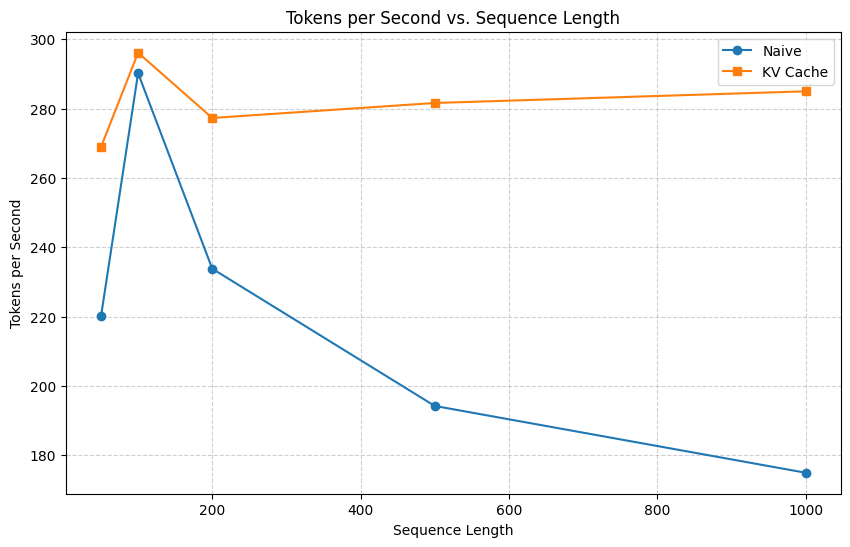

In [ ]:
# Plot 1: Tokens per second comparison
plt.figure(figsize=(10, 6))
plt.plot(benchmark[benchmark["method"] == "naive"]["seq_len"], benchmark[benchmark["method"] == "naive"]["tokens/sec"], marker='o', label="Naive")
plt.plot(benchmark[benchmark["method"] == "kvcache"]["seq_len"], benchmark[benchmark["method"] == "kvcache"]["tokens/sec"], marker='s', label="KV Cache")
plt.title("Tokens per Second vs. Sequence Length")
plt.xlabel("Sequence Length")
plt.ylabel("Tokens per Second")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.savefig("results/kv_benchmark_tokens_sec.png")
plt.show()
plt.close()

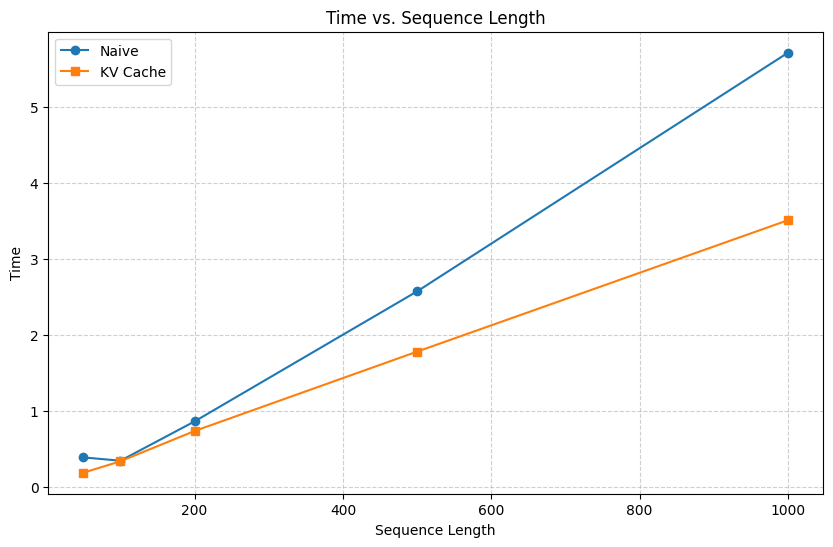

In [ ]:
# Plot 2: Time comparison
plt.figure(figsize=(10, 6))
plt.plot(benchmark[benchmark["method"] == "naive"]["seq_len"], benchmark[benchmark["method"] == "naive"]["time"], marker='o', label="Naive")
plt.plot(benchmark[benchmark["method"] == "kvcache"]["seq_len"], benchmark[benchmark["method"] == "kvcache"]["time"], marker='s', label="KV Cache")
plt.title("Time vs. Sequence Length")
plt.xlabel("Sequence Length")
plt.ylabel("Time")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.savefig("results/kv_benchmark_time.png")
plt.show()
plt.close()

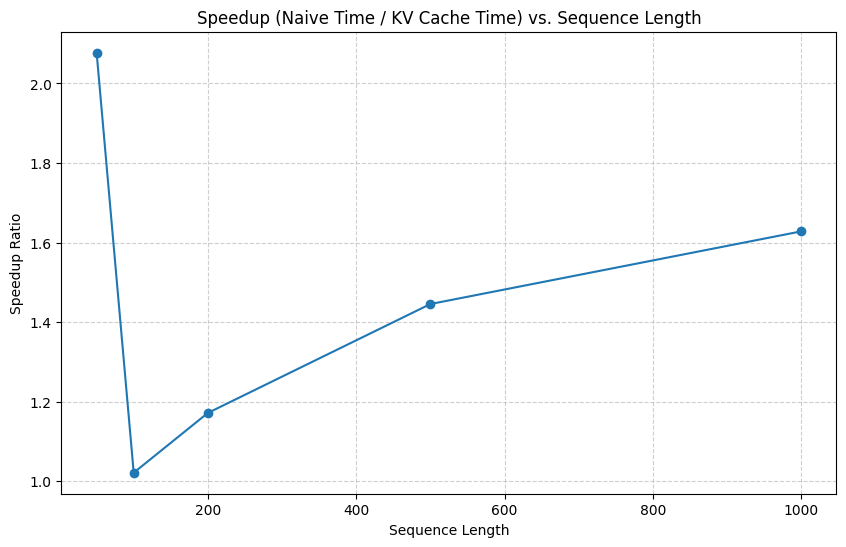

In [ ]:
# Plot 3: Speedup ratio
pivot_df = benchmark.pivot(
    index="seq_len",
    columns="method",
    values="time"
).reset_index()

pivot_df["speedup"] = pivot_df["naive"] / pivot_df["kvcache"]

plt.figure(figsize=(10, 6))
plt.plot(pivot_df["seq_len"], pivot_df["speedup"], marker='o')
plt.title("Speedup (Naive Time / KV Cache Time) vs. Sequence Length")
plt.xlabel("Sequence Length")
plt.ylabel("Speedup Ratio")
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("results/kv_benchmark_speedup.png")
plt.show()
plt.close()

**Iterative-Level Scheduling aka Continuous Batching**

In [36]:
import random

torch.manual_seed(42)

model = GPT(
    vocab_size=50257,
    model_dim=512,
    num_heads=12,
    num_kv_heads=6,
    context_length=256,
    num_blocks=4
)
model.eval()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

GPT(
  (word_embeddings): Embedding(50257, 512)
  (pos_embeddings): Embedding(256, 512)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (attention): GroupedQueryAttention(
        (q_proj): Linear(in_features=512, out_features=504, bias=False)
        (k_proj): Linear(in_features=512, out_features=252, bias=False)
        (v_proj): Linear(in_features=512, out_features=252, bias=False)
        (output_proj): Linear(in_features=504, out_features=512, bias=False)
      )
      (linear_network): VanillaNeuralNetwork(
        (up_projection): Linear(in_features=512, out_features=2048, bias=True)
        (relu): ReLU()
        (down_projection): Linear(in_features=2048, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (first_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (second_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
  )
  (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (p

In [53]:
batch_sizes = [1, 2, 4, 8, 16, 32, 64]
total_requests = 100

# Adjust random lengths to ensure total length <= context_length (256)
prompt_lengths = [random.randint(10, 128) for _ in range(total_requests)]
# randomized max_new_tokens (20 to 100)
max_new_tokens = [random.randint(20, 128) for _ in range(total_requests)]
total_tokens = sum(max_new_tokens)

prompts = [[random.randint(0, 50256) for _ in range(prompt_lengths[i])] for i in range(total_requests)]

results = {}

for batch_size in batch_sizes:
    server = InferenceServer(model, device, max_batch_size=batch_size)

    for i in range(total_requests):
        server.add_request(request_id=i, prompt_tokens=prompts[i], max_new_tokens=max_new_tokens[i])

    start = time.time()
    while len(server.request_queue) > 0:
        server.step()
    end = time.time()
    print(f"Batch size {batch_size}: {end - start:.4f}s")

    metric = total_tokens / (end - start)
    results[batch_size] = metric

Batch size 1: 32.6008s
Batch size 2: 18.5529s
Batch size 4: 11.9877s
Batch size 8: 9.5478s
Batch size 16: 7.2066s
Batch size 32: 7.9588s
Batch size 64: 8.0432s


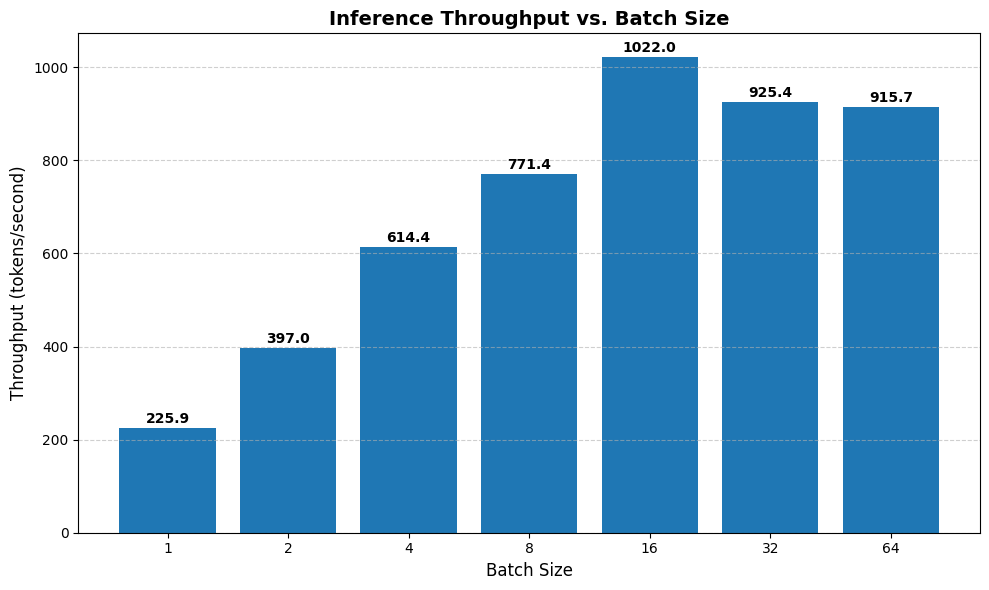

In [ ]:
import numpy as np

throughput = results.values()

plt.figure(figsize=(10, 6))
plt.bar([str(b) for b in results.keys()], throughput)

plt.xlabel("Batch Size", fontsize=12)
plt.ylabel("Throughput (tokens/second)", fontsize=12)
plt.title("Inference Throughput vs. Batch Size", fontsize=14, fontweight='bold')

# Adding value labels on top of bars for clarity
for i, v in enumerate(throughput):
    plt.text(i, v + (max(throughput) * 0.01), f"{v:.1f}", ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('results/cont_batch_benchmark.png')
plt.show()
plt.close()